# SafePrice Simulator
## Conformal Prediction

In [76]:
import joblib
import os
import pandas as pd
import numpy as np
from mapie.regression.regression import _MapieRegressor as MapieRegressor
from mapie.metrics.regression import regression_coverage_score, regression_mean_width_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.compose import TransformedTargetRegressor

### 1) Load Models and Dataset

In [77]:
root_path = os.path.dirname(os.getcwd())

models_path = os.path.join(root_path, 'models')
best_ebm = joblib.load(os.path.join(models_path, 'fitted_ebm_final.pkl'))

cleaned_data_path = os.path.join(root_path, "datasets/cleaned")
X_train = pd.read_csv(os.path.join(cleaned_data_path, 'X_train.csv'))
y_train = pd.read_csv(os.path.join(cleaned_data_path, 'y_train.csv'))
X_test = pd.read_csv(os.path.join(cleaned_data_path, 'X_test.csv'))
y_test = pd.read_csv(os.path.join(cleaned_data_path, 'y_test.csv'))

### 2) Mapie Implementation (Conformal Interval Generate)

In [78]:
log_ebm = TransformedTargetRegressor(
    regressor=best_ebm,
    func=np.log1p,       
    inverse_func=np.expm1  
)

In [79]:
X_train_fit, X_cal, y_train_fit, y_cal = train_test_split(
    X_train, y_train, test_size=0.2, random_state=1111
)

log_ebm.fit(X_train_fit, y_train_fit.values.ravel())

mapie_cv = MapieRegressor(estimator=log_ebm, cv="prefit")
mapie_cv.fit(X_cal, y_cal.values.ravel())

y_preds, y_pis = mapie_cv.predict(X_test, alpha=0.05)

lower_bounds_final = np.maximum(0, y_pis[:, 0, 0])
upper_bounds = y_pis[:, 1, 0]

print("Conformal intervals generated and clipped at zero.")

Conformal intervals generated and clipped at zero.


### 3) Evaluatin Risk Metrics

In [80]:
y_intervals = np.stack([lower_bounds_final, upper_bounds], axis=1)[:, :, np.newaxis]

actual_coverage = regression_coverage_score(
    y_test.values.ravel(),
    y_intervals
)

avg_width = regression_mean_width_score(y_intervals)

alpha = 0.05
print(f"--- Risk Analysis Results ---")
print(f"Target Coverage: {(1 - alpha) * 100:.2f}%")
print(f"Actual Coverage: {actual_coverage[0] * 100:.2f}%")
print(f"Coverage Gap: {((1 - alpha) - actual_coverage[0]) * 100:.2f}%")
print(f"Avg Interval Width: {avg_width[0]:.2f} units")

--- Risk Analysis Results ---
Target Coverage: 95.00%
Actual Coverage: 94.17%
Coverage Gap: 0.83%
Avg Interval Width: 31.59 units


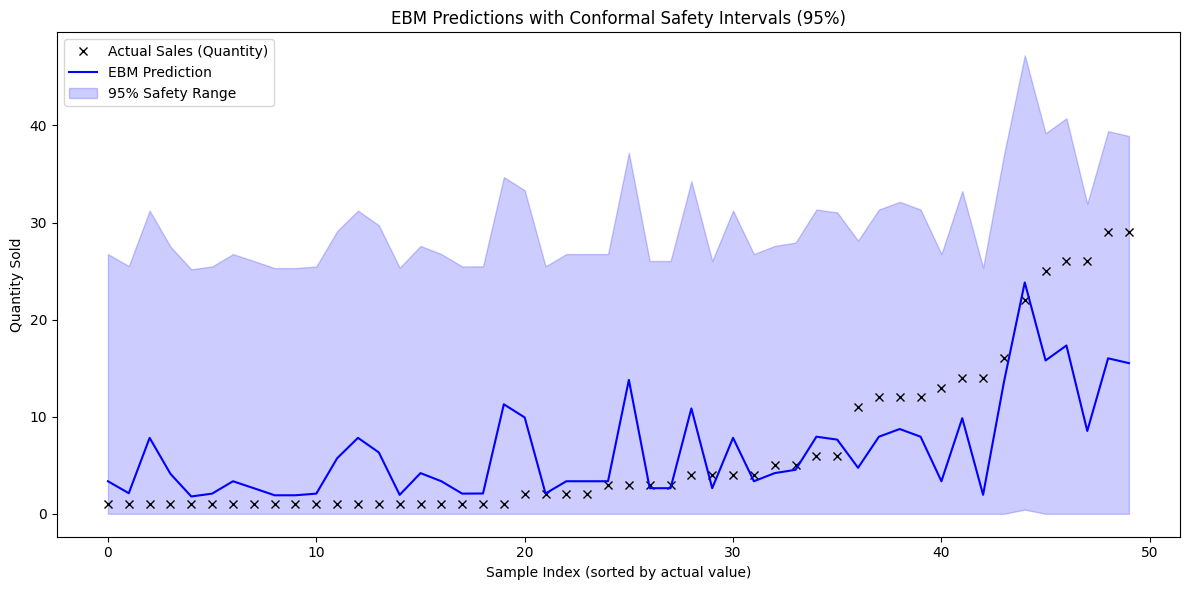

In [ ]:
sample_size = 50
indices = np.argsort(y_test.values.ravel()[:sample_size])

y_test_plot  = y_test.values.ravel()[:sample_size][indices]
y_preds_plot = y_preds.ravel()[:sample_size][indices]  
lower_plot   = lower_bounds_final[:sample_size][indices]
upper_plot   = upper_bounds[:sample_size][indices]

plt.figure(figsize=(12, 6))
plt.plot(y_test_plot,  'kx', label="Actual Sales (Quantity)")
plt.plot(y_preds_plot, 'b-', label="EBM Prediction")
plt.fill_between(
    range(len(y_test_plot)), 
    lower_plot, 
    upper_plot, 
    color='blue', alpha=0.2, 
    label="95% Safety Range" 
)

plt.title("EBM Predictions with Conformal Safety Intervals (95%)")
plt.xlabel("Sample Index (sorted by actual value)")
plt.ylabel("Quantity Sold")
plt.legend()
plt.tight_layout()
plt.show()

In [82]:
joblib.dump(mapie_cv, os.path.join(models_path, 'risk_aware_ebm.pkl'))

['/Users/admin/Desktop/MSC (DS)/Major Project/SafePrice Simulator/models/risk_aware_ebm.pkl']